In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import rasterio
import os

In [20]:
def load_tiff(file_path):
    """Reads TIFF. Returns 330x330 if low_res=True, else full 990x990."""
    with rasterio.open(file_path) as src:
        img_data = src.read()           

    return img_data

def preprocess_image(img_data):
    """Converts to float32 and sets -10000 to NaN."""
    img_data = img_data.astype(np.float32) 
    img_data[img_data == -10000] = np.nan
    img_data /= 10_000  # Normalize to [0, 1]
    return img_data

In [42]:
pred_path = os.path.join('..', 'dataset', 'change_detection', 'hr_mae_FORECAST_50_327.0', '330_2022-12-21_hr_mae_FORECAST_50_327.0_pred.tif')
ref_path = os.path.join('..', 'dataset', 'change_detection', 'hr_mae_FORECAST_50_327.0', '330_2022-12-21_hr_mae_FORECAST_50_327.0_ref.tif')

img_ref = preprocess_image(load_tiff(ref_path))
img_pred = preprocess_image(load_tiff(pred_path))

In [76]:
def get_rgb_image(img_data):
    """Extracts Red(B4), Green(B3), Blue(B2) and applies a basic contrast stretch."""
    # indices: B4=2, B3=1, B2=0
    rgb = np.stack([img_data[2], img_data[1], img_data[0]], axis=-1)
    # Clip and scale to 0-1 for matplotlib, replacing NaNs with 0 (black) for the RGB view
    rgb = np.nan_to_num(rgb, nan=0.0)
    return np.clip(rgb / 0.3, 0, 1)

def display_HSI(image, title=""):
    """Displays the first 3 bands as RGB."""

    band_names = ['B2 (Blue)', 'B3 (Green)', 'B4 (Red)', 'B5 (Red Edge 1)', 
                  'B6 (Red Edge 2)', 'B7 (Red Edge 3)', 'B8 (NIR)', 
                  'B8A (Narrow NIR)', 'B11 (SWIR 1)', 'B12 (SWIR 2)']

    # Setup GridSpec: 2 rows, 7 columns
    subplot_size = 4 
    fig = plt.figure(figsize=(7*subplot_size, 2*subplot_size))
    gs = gridspec.GridSpec(2, 7, figure=fig)
    
    all_axes = []
    
    # 1. Create the Large RGB Axis (spans rows 0-1, cols 0-1)
    ax_rgb = fig.add_subplot(gs[0:2, 0:2])
    im_rgb = ax_rgb.imshow(get_rgb_image(image), extent=[0, 990, 990, 0])
    ax_rgb.set_title("True Color (RGB)")
    ax_rgb.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    all_axes.append(ax_rgb)

    # 2. Create the 10 Individual Band Axes (cols 2 to 6)
    band_axes = []
    im_objects = []
    for i in range(10):
        row = i // 5
        col = (i % 5) + 2
        # Link panning/zooming to the RGB axis
        ax = fig.add_subplot(gs[row, col], sharex=ax_rgb, sharey=ax_rgb) 
        band_axes.append(ax)
        all_axes.append(ax)
        
        im = ax.imshow(image[i], cmap='gray', extent=[0, 990, 990, 0])  # vmin=0, vmax=0.30
        ax.set_title(band_names[i])
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        im_objects.append(im)
        
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.suptitle(title, fontsize=16)
    plt.subplots_adjust(top=0.92)

-0.01 0.3948
(10, 105, 105)
-0.0064 0.4586
(10, 105, 105)
-0.2477 0.1209
(10, 105, 105)


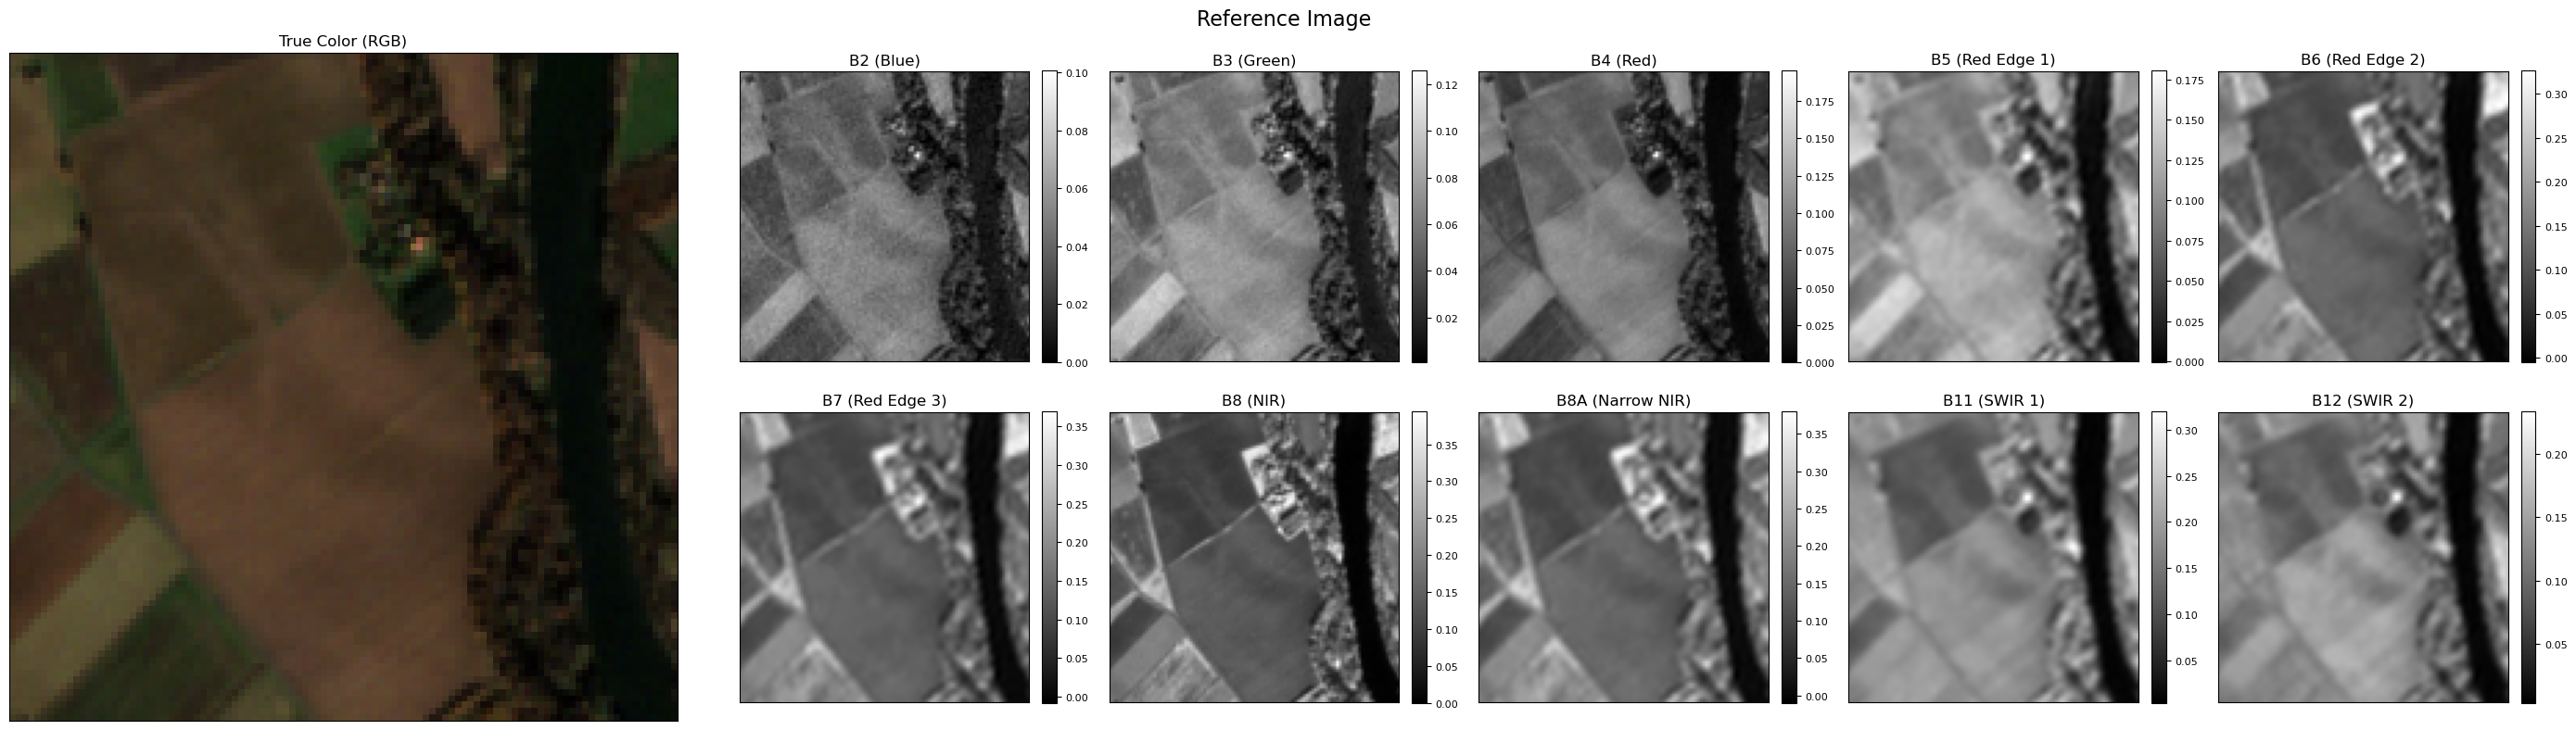

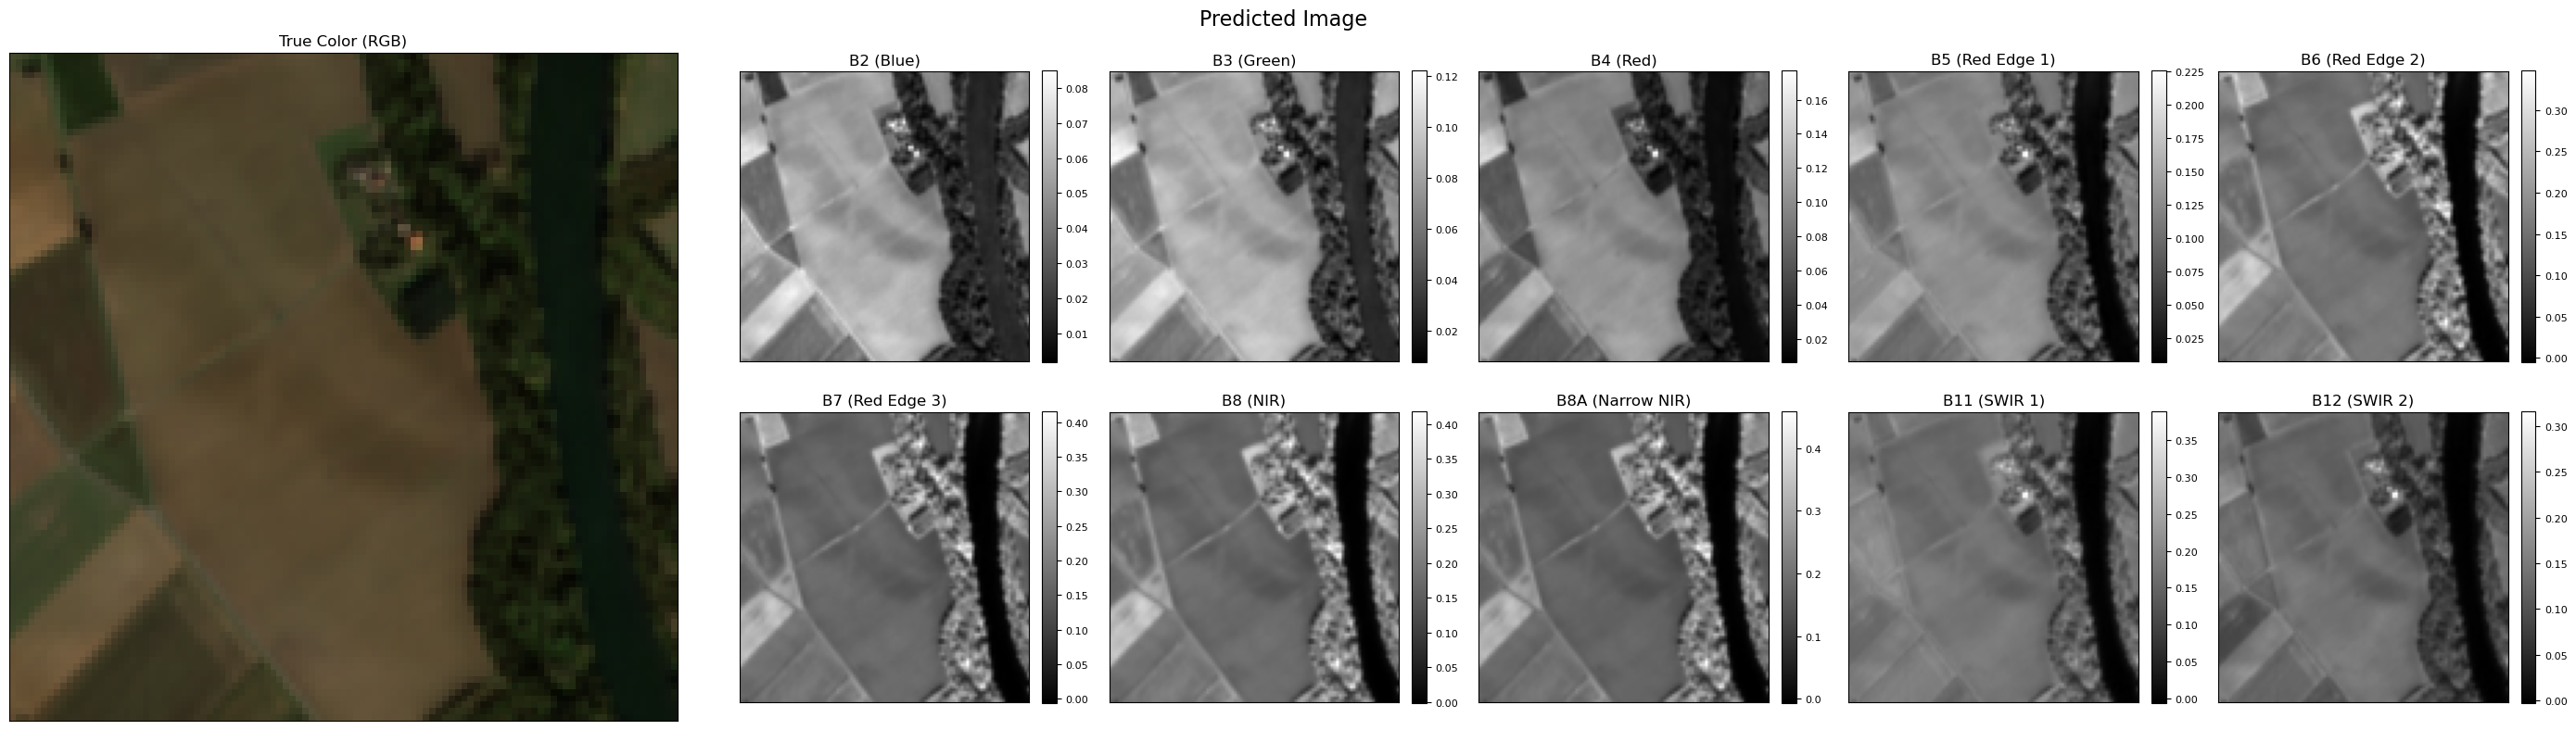

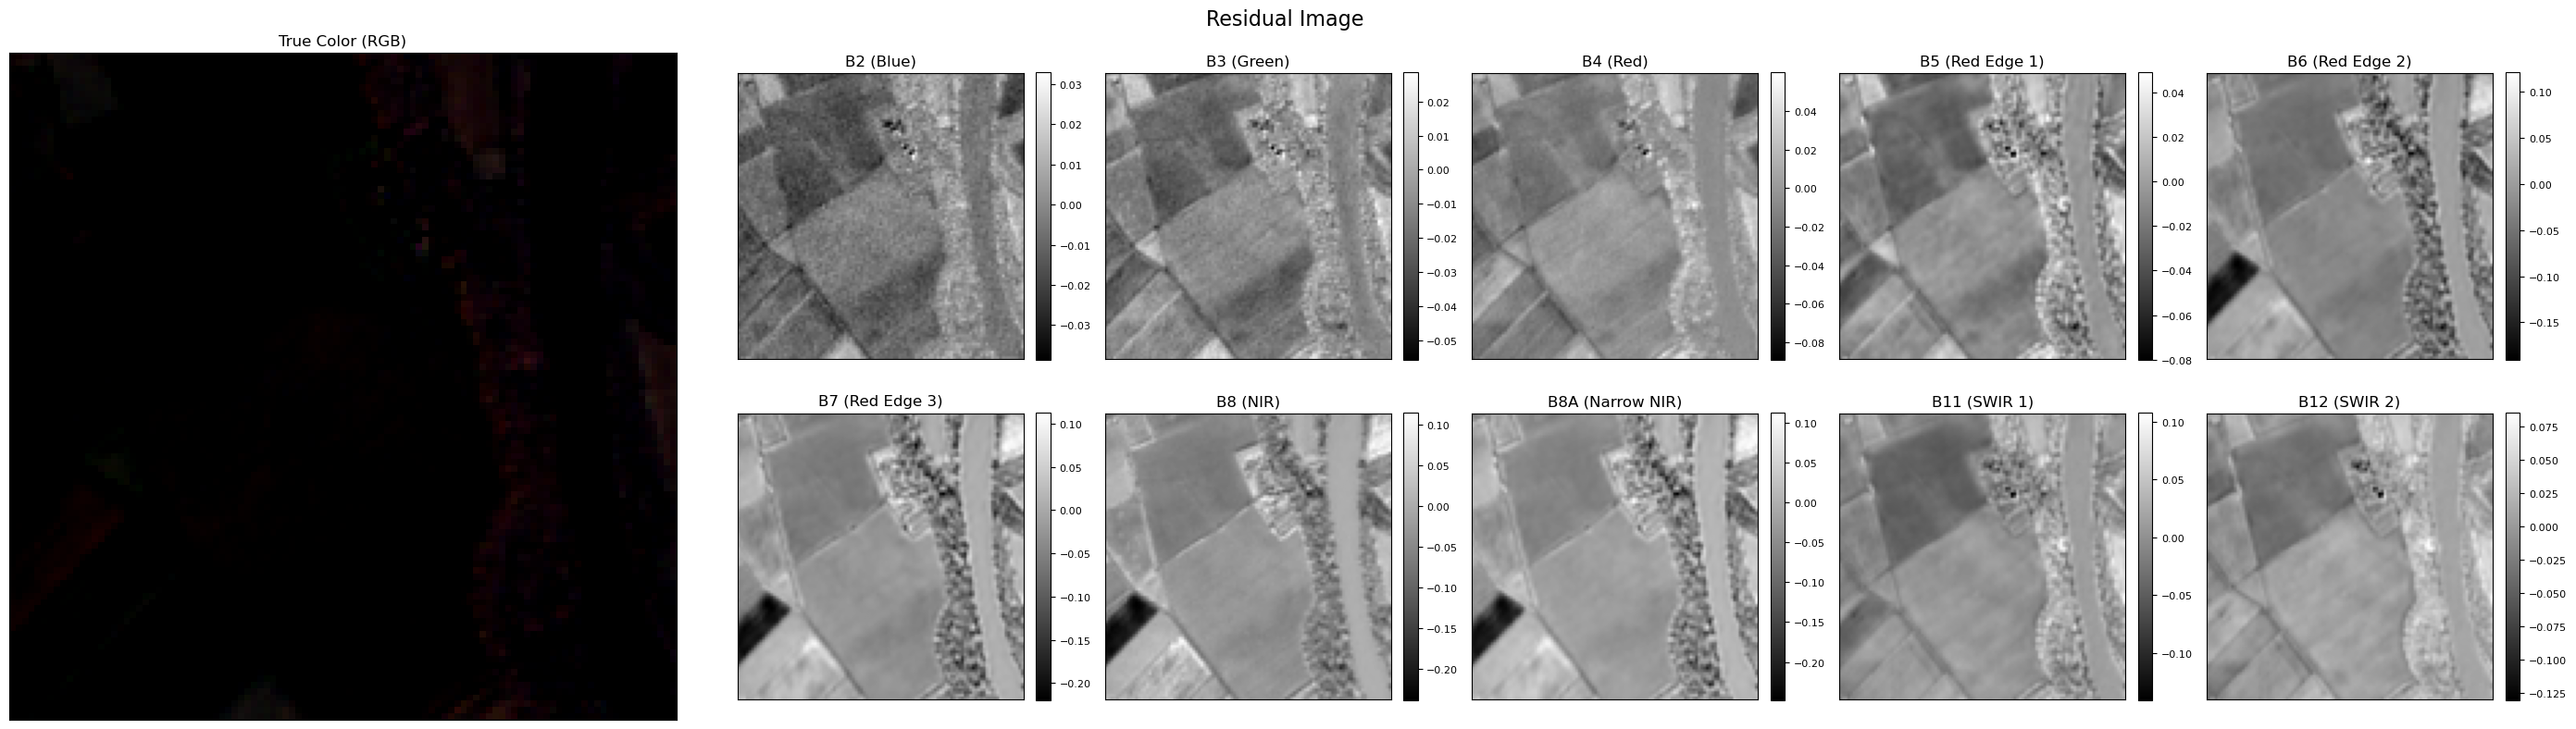

In [77]:
print(np.min(img_ref), np.max(img_ref))
print(img_ref.shape)
display_HSI(img_ref, title="Reference Image")

print(np.min(img_pred), np.max(img_pred))
print(img_pred.shape)
display_HSI(img_pred, title="Predicted Image")

img_res = img_ref - img_pred
print(np.min(img_res), np.max(img_res))
print(img_res.shape)
display_HSI(img_res, title="Residual Image")

In [78]:
from scipy.ndimage import convolve

def compute_variance_map(residual, outer_diameter=7, inner_diameter=3):
    """
    Computes a spatial variance map for each band using a torus neighborhood.
    Assumes residual shape is (Bands, Height, Width) e.g., (10, 105, 105).
    """
    img_var = np.zeros_like(residual)
    
    # 1. Define the torus (annulus) kernel
    r_out = outer_diameter // 2
    r_in = inner_diameter // 2
    
    # Create a grid to measure distances from the center
    y, x = np.ogrid[-r_out:r_out+1, -r_out:r_out+1]
    dist_sq = x**2 + y**2
    
    # Create boolean mask: True inside outer circle AND outside inner circle
    mask = (dist_sq <= r_out**2) & (dist_sq > r_in**2)
    
    # Convert mask to float and normalize so it acts as an averaging filter
    kernel = mask.astype(float)
    kernel_sum = np.sum(kernel)
    
    if kernel_sum == 0:
        raise ValueError("Inner diameter is too large compared to outer diameter, resulting in an empty mask.")
        
    kernel /= kernel_sum
    
    # 2. Compute the variance for each band using convolutions
    for b in range(residual.shape[0]):
        band = residual[b]
        
        # E[X]: The mean of the pixels in the torus
        mean_x = convolve(band, kernel, mode='reflect')
        
        # E[X^2]: The mean of the squared pixels in the torus
        mean_x2 = convolve(band**2, kernel, mode='reflect')
        
        # Var(X) = E[X^2] - (E[X])^2
        variance = mean_x2 - (mean_x**2)
        
        # Floating point math can sometimes create tiny negative numbers near zero.
        # We clip them at 0 to keep the variance strictly positive.
        img_var[b] = np.maximum(variance, 0)
        
    return img_var

3.6414986e-07 0.010224435
(10, 105, 105)


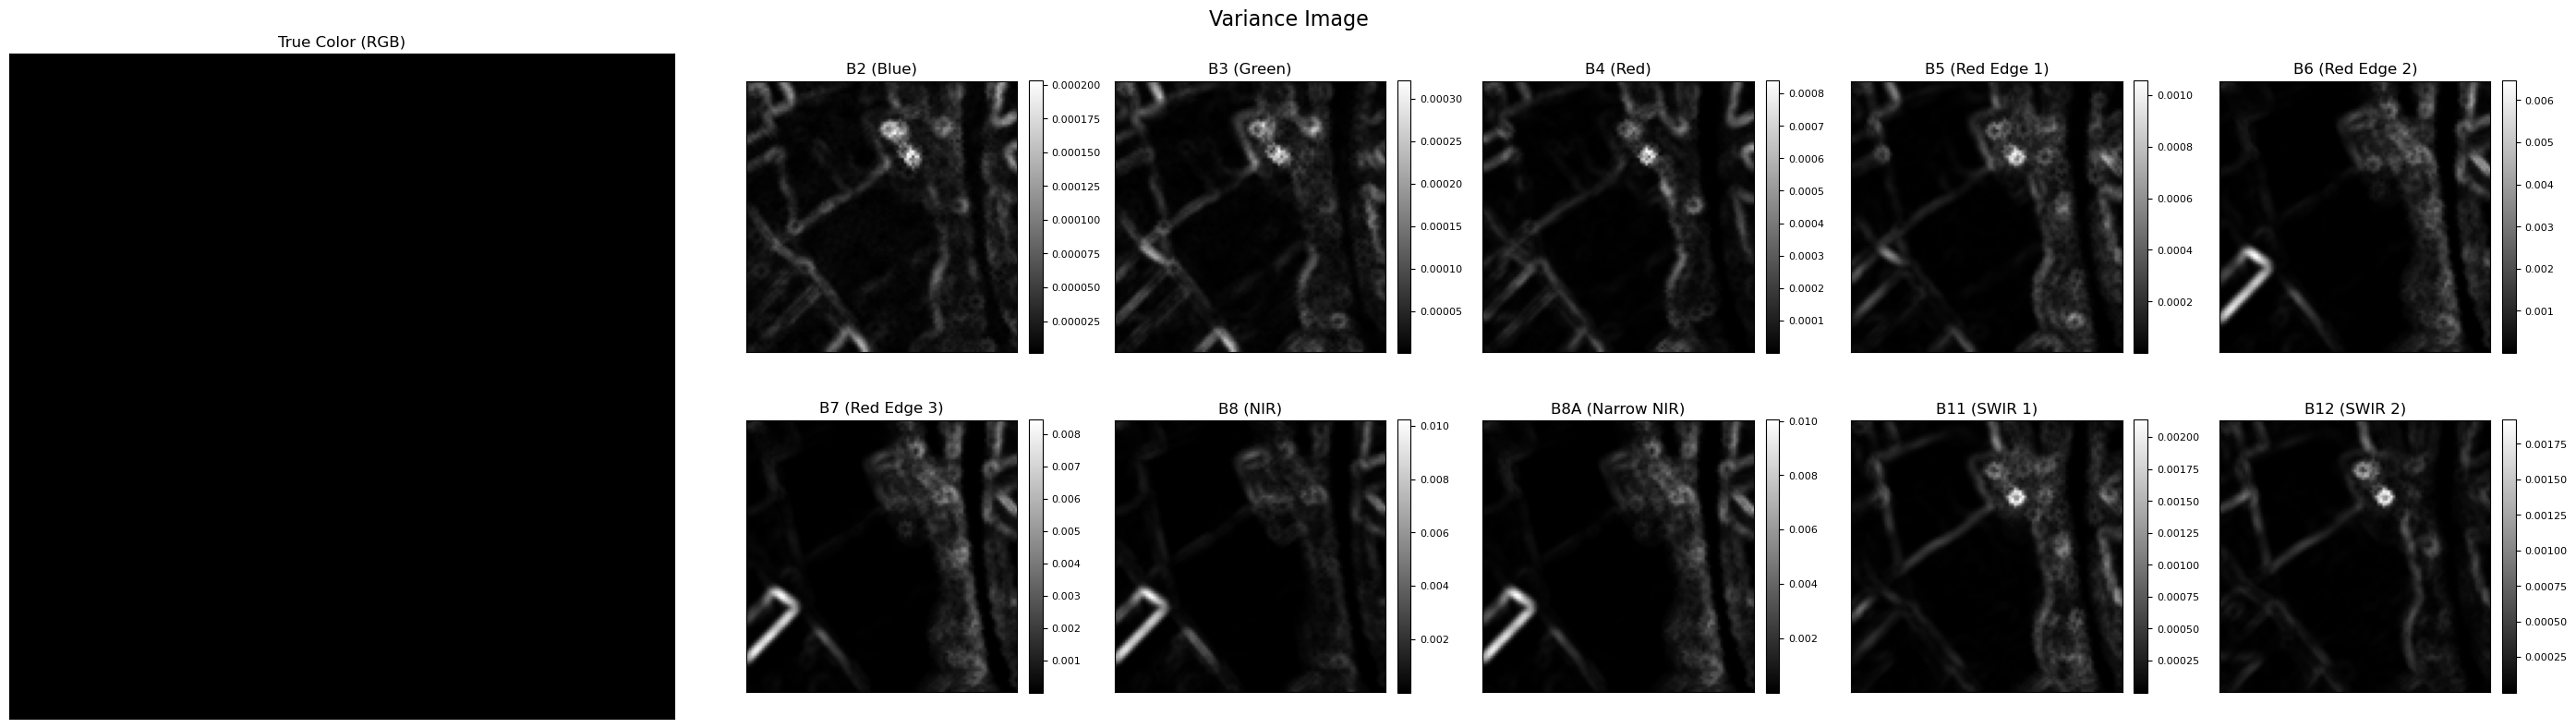

In [79]:
img_var = compute_variance_map(img_res)
print(np.min(img_var), np.max(img_var))
print(img_var.shape)
display_HSI(img_var, title="Variance Image")

-56.096127 24.8626
(10, 105, 105)


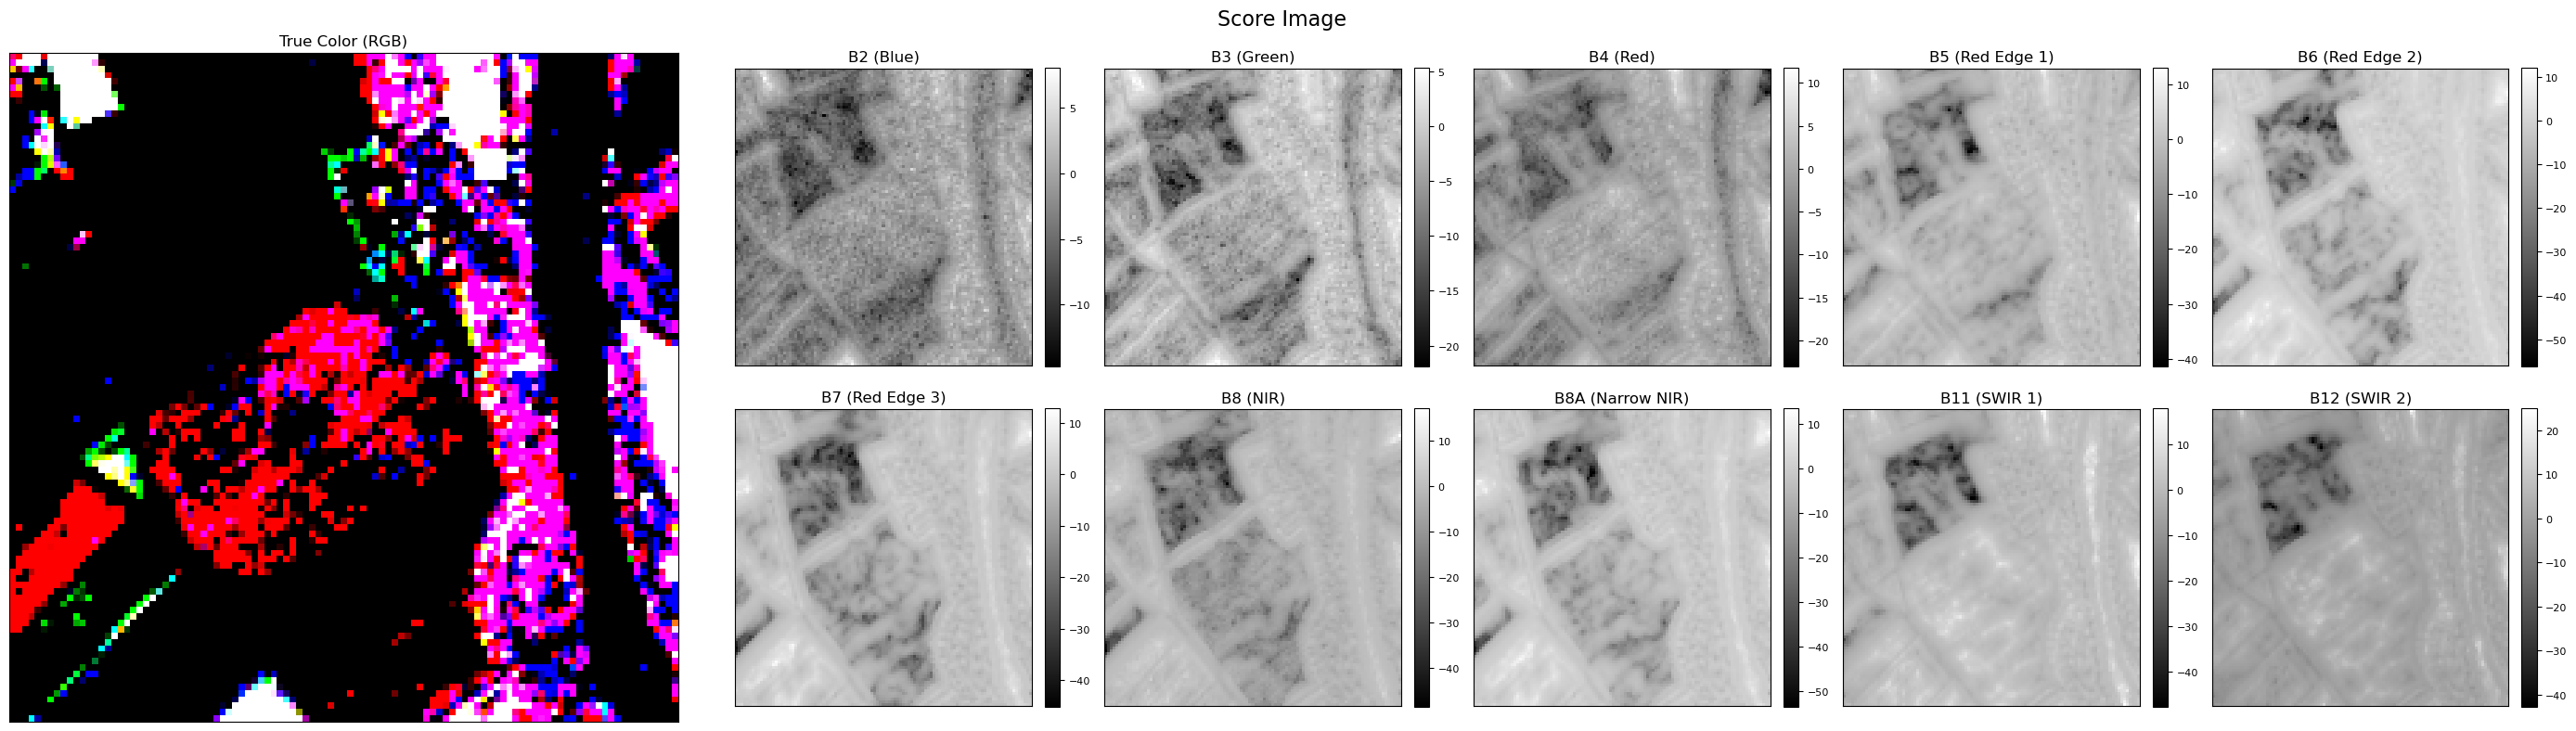

In [80]:
img_score = img_res / np.sqrt(img_var + 1e-8)  # Adding a small constant to avoid division by zero
print(np.min(img_score), np.max(img_score))
print(img_score.shape)
display_HSI(img_score, title="Score Image")


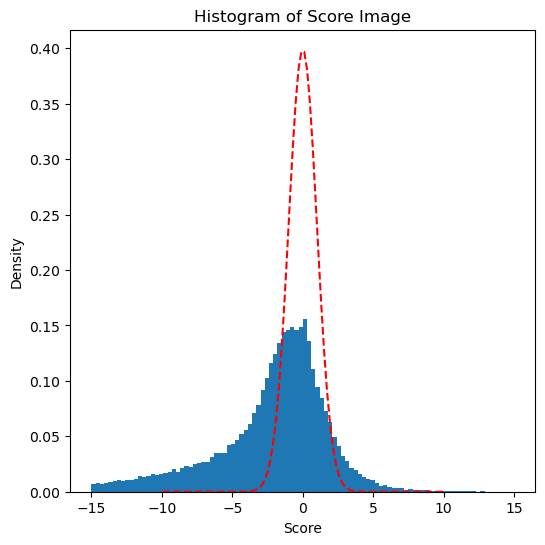

In [88]:
from scipy.stats import norm

plt.figure(figsize=(6, 6))
plt.hist(img_score.flatten(), bins=100, range=(-15, 15), density=True)
x = np.linspace(-10, 10, 100)
plt.plot(x, norm.pdf(x), color='red', linestyle='--')  # Normal distribution curve for reference
plt.title("Histogram of Score Image")
plt.xlabel("Score")
plt.ylabel("Density")
plt.show()

False True
(10, 105, 105)


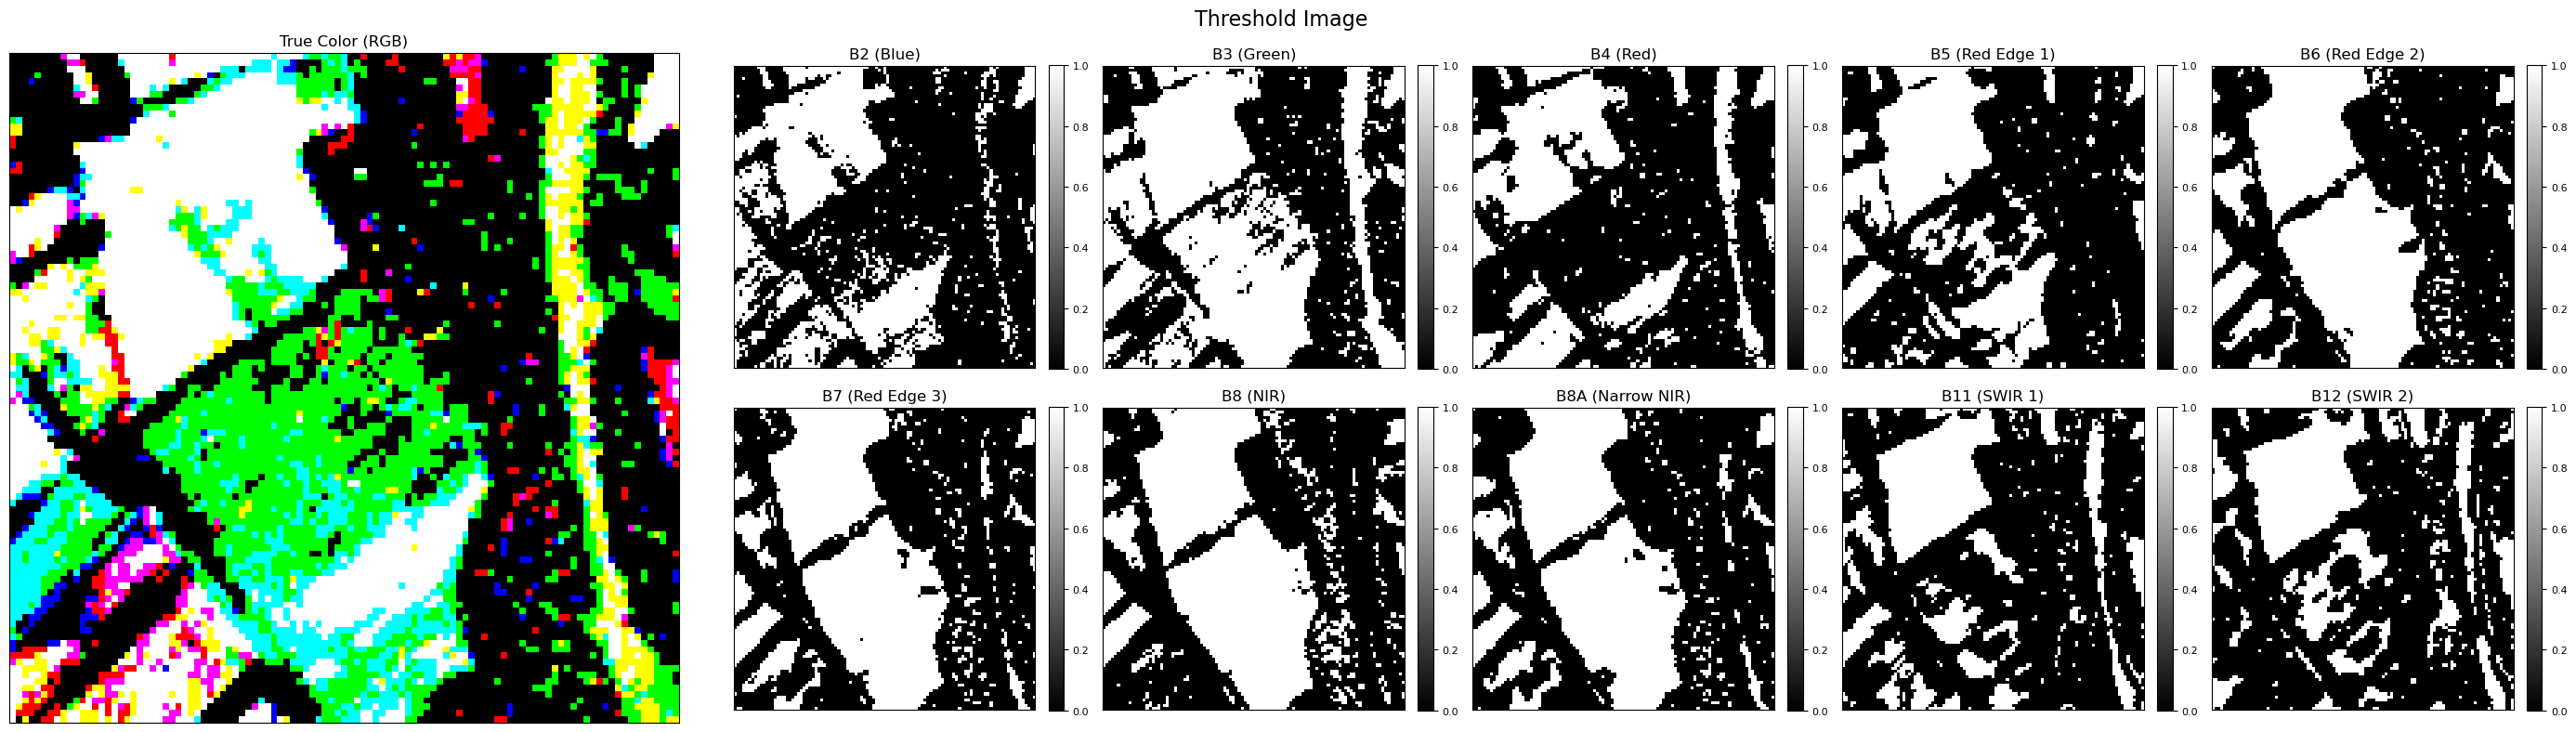

In [81]:
img_thresh = (img_score < -3) | (img_score > 3)  # Thresholding at a score of 3 (this can be adjusted based on the distribution of scores)
print(np.min(img_thresh), np.max(img_thresh))
print(img_thresh.shape)
display_HSI(img_thresh, title="Threshold Image")